# MVP — Análise de Fraude em Transações (IEEE-CIS Fraud Detection)

**Nome:** Raphael Santiago Pereira
**Matrícula:** 4052026000041
**Data:** 08/07/2026
**Dataset:** IEEE-CIS Fraud Detection (Kaggle) — https://www.kaggle.com/competitions/ieee-fraud-detection/overview
**Tipo de problema:** Classificação binária (detecção de fraude), com forte desbalanceamento de classes e componente temporal

---

## Sobre este notebook

Este notebook contém o fluxo completo do MVP da Sprint de Machine Learning & Analytics — definição do problema, entendimento e preparação dos dados, modelagem, avaliação e discussão crítica dos resultados — aplicado ao desafio Kaggle **IEEE-CIS Fraud Detection**.

> **Execução no Google Colab:** execute todas as células em sequência, do início ao fim (`Ambiente de execução > Executar tudo`). Os dados são baixados automaticamente na Seção 3.2 a partir de um mirror público no Google Drive — não é necessário nenhum upload manual nem montar um Google Drive pessoal. Veja o `README.md` do repositório para detalhes sobre a origem dos dados e o tempo estimado de execução (o treinamento do ensemble final é computacionalmente pesado).


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

Fraude em transações de cartão "card-not-present" (compras online) representa perdas financeiras diretas para processadoras de pagamento e para os consumidores lesados, além de custos indiretos com contestações e investigações manuais. Bloquear transações fraudulentas em tempo real é difícil porque fraudadores representam uma fração muito pequena do volume total de transações e adaptam continuamente seu comportamento para se parecer com clientes legítimos.

Este projeto usa o dataset da competição Kaggle **IEEE-CIS Fraud Detection**, disponibilizado pela Vesta Corporation, contendo transações reais anonimizadas rotuladas como fraudulentas (`isFraud = 1`) ou legítimas (`isFraud = 0`), acompanhadas de centenas de atributos transacionais e de identidade do dispositivo/rede.

O modelo resultante apoiaria uma equipe de risco/antifraude na priorização de transações suspeitas para revisão manual ou bloqueio automático, funcionando como um score de risco complementar às regras de negócio já existentes.


## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**
> Construir e avaliar modelos de Machine Learning para prever a probabilidade de fraude (`isFraud`) em transações de cartão, comparando um baseline aleatório com modelos de gradient boosting (XGBoost, LightGBM, CatBoost) e um ensemble via stacking, discutindo o trade-off entre precisão e recall e as limitações práticas da solução.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação binária.

**Justificativa:** o target `isFraud` assume apenas dois valores (0/1). Além disso, o problema tem um componente temporal relevante — as transações têm um timestamp relativo (`TransactionDT`) — o que exige tratar a divisão treino/teste de forma ordenada no tempo, e não com validação cruzada aleatória ou embaralhamento ingênuo, para não simular acesso ao futuro durante o treino.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Transações com valores "redondos" (poucos centavos) podem ser mais comuns em fraude do que em compras legítimas — o "cents trick": compras legítimas costumam ter centavos decorrentes de impostos/frete, enquanto fraudadores testam valores redondos.
2. A hora do dia e o dia da semana carregam sinal preditivo sobre a probabilidade de fraude (padrões de uso diferem entre clientes legítimos e fraudadores).
3. Informações históricas sobre as entidades da transação (frequência de uso de um cartão/endereço, taxa de fraude histórica associada a um cartão/e-mail/dispositivo) agregam poder preditivo além dos atributos brutos da transação.

**Critérios de sucesso:**
- Métrica principal: ROC-AUC — adequada a um problema de classificação binária fortemente desbalanceado, pois não depende de um threshold fixo.
- Resultado mínimo esperado: ROC-AUC substancialmente acima de 0,50 (equivalente a um classificador aleatório).
- Restrição prática: dado o custo assimétrico entre deixar passar uma fraude (perda financeira direta) e bloquear indevidamente um cliente legítimo (atrito/perda de receita), o threshold de decisão final deve priorizar recall sobre precisão — métrica F2, que pondera recall com peso duplo em relação à precisão.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [ ]:
# === Instalação das dependências (executa ANTES dos imports) ===
# No Google Colab, category_encoders e catboost não vêm pré-instalados; instale-os
# antes de qualquer import para que o notebook rode do início ao fim sem erros.
!pip install -q gdown category_encoders lightgbm catboost xgboost

# === Setup e reprodutibilidade ===
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, fbeta_score, roc_auc_score, classification_report,
    RocCurveDisplay
)

import category_encoders as ce
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

SEED = 42

def set_seed(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed()
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências e versões

As bibliotecas indispensáveis ao projeto (`gdown`, `category_encoders`, `lightgbm`, `catboost`, `xgboost`) são instaladas no início da célula de setup acima — antes dos imports — para que o notebook execute do início ao fim no Google Colab sem erros de módulo não encontrado. A célula abaixo apenas registra as versões carregadas, para fins de reprodutibilidade.


In [ ]:
# === Versões das bibliotecas (reprodutibilidade) ===
# As dependências já foram instaladas na célula anterior, junto com os imports.
# Esta célula apenas registra as versões efetivamente carregadas no ambiente.
import sklearn, xgboost, lightgbm, catboost, category_encoders

for _lib in [np, pd, sklearn, xgboost, lightgbm, catboost, category_encoders]:
    print(f"{_lib.__name__:>18}: {_lib.__version__}")


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [ ]:
def reduce_mem_usage(df, verbose=True):
    """Reduz o uso de memória de um DataFrame fazendo downcast de colunas numéricas."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    if verbose:
        end_mem = df.memory_usage().sum() / 1024**2
        print(f'Memória reduzida para {end_mem:.2f} Mb (redução de {100 * (start_mem - end_mem) / start_mem:.1f}%)')
    return df


def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan
    return results


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** IEEE-CIS Fraud Detection — Kaggle (https://www.kaggle.com/competitions/ieee-fraud-detection/overview), disponibilizado pela Vesta Corporation.

**Por que esse dataset foi escolhido:** é um problema real de classificação binária fortemente desbalanceada, com forte componente temporal e de engenharia de atributos — um cenário diferente dos datasets utilizados em aula e representativo de um problema real de antifraude.

**Restrições consideradas:** os arquivos oficiais (`train_transaction.csv`, `train_identity.csv`, `test_transaction.csv`, `test_identity.csv`) ultrapassam 500MB cada e não podem ser versionados no GitHub. Por isso, foram espelhados numa pasta pública do Google Drive (link no `README.md` do repositório), usada exclusivamente para fins de execução acadêmica deste MVP — sem redistribuição comercial. Apenas `train_transaction.csv`/`train_identity.csv` (que contêm o rótulo `isFraud`) são usados neste notebook; o split treino/teste é construído a partir deles, já que o conjunto de teste oficial do Kaggle não tem rótulos públicos e não permitiria avaliação.

**Ética/licença:** os dados são anonimizados pela Vesta (nomes de colunas como `V1`...`V339` não têm significado divulgado publicamente); uso restrito a fins educacionais, conforme os termos da competição Kaggle.


## 3.2 Carga dos dados

Os dados são baixados automaticamente do mirror público no Google Drive via `gdown` — sem necessidade de upload manual ou de montar um Google Drive pessoal.


In [ ]:
# === Carga dos dados ===
import gdown

DATA_PATH = './data/'
os.makedirs(DATA_PATH, exist_ok=True)

FOLDER_URL = "https://drive.google.com/drive/folders/1NL-VsVQ-P3VX3ASD-74aiWa8FA_6cVBY"
gdown.download_folder(url=FOLDER_URL, output=DATA_PATH, quiet=False, use_cookies=False)

train_transaction = pd.read_csv(os.path.join(DATA_PATH, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(DATA_PATH, 'train_identity.csv'))

train_transaction = reduce_mem_usage(train_transaction)
train_identity = reduce_mem_usage(train_identity)

df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df = df_train  # alias para reaproveitar as células de visão geral abaixo

df.head()


,idade_cliente,renda_mensal,tempo_relacionamento_meses,canal_aquisicao,usa_app,churn
0,56,3712.453323,109,indicação,sim,0
1,69,6223.275948,98,orgânico,sim,0
2,46,3685.340063,87,indicação,sim,0
3,32,5389.625461,37,orgânico,sim,0
4,60,5082.029312,75,ads,sim,0


## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (500, 6)

Tipos de dados:


,tipo
idade_cliente,int64
renda_mensal,float64
tempo_relacionamento_meses,int64
canal_aquisicao,object
usa_app,object
churn,int64


In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
idade_cliente,0
renda_mensal,0
tempo_relacionamento_meses,0
canal_aquisicao,0
usa_app,0
churn,0


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df.sample(5, random_state=SEED))

,idade_cliente,renda_mensal,tempo_relacionamento_meses,canal_aquisicao,usa_app,churn
361,58,3459.049113,38,indicação,sim,0
73,21,3991.674128,36,ads,sim,1
374,34,6565.290656,77,orgânico,sim,1
155,22,4053.640961,23,ads,sim,1
104,42,5136.448205,101,orgânico,sim,0


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| TransactionID | identificador | ID único da transação | não | usado só para o merge; removido antes do treino |
| isFraud | alvo | 1 = fraude, 0 = legítima | alvo | forte desbalanceamento (~3,5% de fraude) |
| TransactionDT | numérica (timestamp relativo) | segundos desde uma referência temporal | não (diretamente) | usada para ordenar/dividir os dados e derivar `Hour_of_Day`/`Day_of_Week`; descartada como feature bruta para evitar vazamento |
| TransactionAmt | numérica | valor da transação em dólares | sim | forte assimetria (distribuição aproximadamente log-normal) |
| ProductCD | categórica | código do produto/serviço da transação | sim | baixa cardinalidade |
| card1–card6 | categórica/numérica | atributos do cartão de pagamento (emissor, tipo, banco etc., anonimizados) | sim | `card1` também usado nas features de velocidade/grafo |
| addr1, addr2 | categórica | região/endereço de cobrança | sim | `addr1` também usado nas features de velocidade |
| P_emaildomain, R_emaildomain | categórica | domínio de e-mail do comprador/destinatário | sim | alta cardinalidade → target encoding; também usado nas features de grafo |
| C1–C14 | numérica | contagens anonimizadas (ex.: nº de endereços associados ao cartão) | sim | |
| D1–D15 | numérica | deltas de tempo anonimizados (ex.: dias desde a última transação) | sim | |
| M1–M9 | categórica | flags de correspondência (ex.: nome no cartão bate com endereço) | sim | |
| V1–V339 | numérica | features de engenharia anonimizadas pela Vesta | sim | reduzidas via PCA (90% da variância → 69 componentes) |
| id_01–id_38, DeviceType, DeviceInfo | categórica/numérica | atributos de identidade/dispositivo/rede (tabela `identity`) | sim | muitos valores ausentes — nem toda transação tem dados de identidade |
| Transaction_Cents, Hour_of_Day, Day_of_Week | numérica (derivada) | parte decimal do valor, hora do dia e dia da semana da transação | sim | features de engenharia criadas na Seção 4 |


# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [ ]:
# === Preparação para a EDA: tipos categóricos e feature engineering temporal ===
categorical_features = ['ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain'] + \
                       [f'card{i}' for i in range(1, 7)] + \
                       [f'M{i}' for i in range(1, 10)] + \
                       ['DeviceType', 'DeviceInfo'] + \
                       [f'id_{i}' for i in range(12, 39)]

for col in categorical_features:
    if col in df_train.columns:
        df_train[col] = df_train[col].astype(str)

# feature engineering: novas features a partir das existentes, para capturar padrões temporais
df_train['Transaction_Cents'] = (df_train['TransactionAmt'] % 1).round(3)
df_train['Hour_of_Day'] = np.floor(df_train['TransactionDT'] / 3600) % 24
df_train['Day_of_Week'] = np.floor(df_train['TransactionDT'] / (3600 * 24)) % 7


Distribuição do target:


,contagem
churn,
0,300
1,200


,percentual
churn,
0,60.0
1,40.0


### Análise visual exploratória

Antes de transformar os dados, inspeciono o sinal bruto para motivar as escolhas do pipeline. São examinados: **(a)** o desbalanceamento da classe alvo, **(b)** como o valor das transações difere entre fraude e atividade legítima, **(c)–(d)** os padrões temporais de fraude capturados pelas features `Hour_of_Day`/`Day_of_Week`, e **(e)** a hipótese do "cents trick" por trás de `Transaction_Cents`. Estes gráficos são calculados sobre `df_train`, ainda com o alvo `isFraud` presente (antes do split temporal).


In [ ]:
sns.set_style('white')
PALETTE = ['#4C72B0', '#C44E52']  # [legítima, fraude]

# distribuição da classe alvo: quantifica o desbalanceamento que orienta todas as escolhas de design
fraud_counts = df_train['isFraud'].value_counts().sort_index()
fraud_pct = df_train['isFraud'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Legítima (0)', 'Fraude (1)'], fraud_counts.values, color=PALETTE)
for bar, pct in zip(bars, fraud_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribuição da classe alvo (desbalanceamento)', fontsize=12)
ax.set_ylabel('Número de transações')
plt.tight_layout()
plt.show()

print(f"Taxa de fraude: {fraud_pct[1]:.2f}% de todas as transações ({fraud_counts[1]:,} de {fraud_counts.sum():,})")


In [ ]:
# distribuição de TransactionAmt por classe (escala log)
# transformação log porque os valores são fortemente assimétricos à direita; revela se a
# fraude favorece determinadas faixas de valor
fig, ax = plt.subplots(figsize=(7, 4))
for label, color, name in [(0, PALETTE[0], 'Legítima'), (1, PALETTE[1], 'Fraude')]:
    subset = df_train.loc[df_train['isFraud'] == label, 'TransactionAmt']
    ax.hist(np.log1p(subset), bins=60, alpha=0.6, density=True, color=color, label=name)
ax.set_title('Distribuição do valor da transação por classe')
ax.set_xlabel('log(1 + TransactionAmt)')
ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# taxa de fraude por hora do dia e dia da semana
# valida as features temporais criadas: se a taxa de fraude varia ao longo do tempo, essas
# features carregam sinal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hourly_fraud = df_train.groupby('Hour_of_Day')['isFraud'].mean() * 100
axes[0].bar(hourly_fraud.index, hourly_fraud.values, color=PALETTE[1])
axes[0].axhline(fraud_pct[1], color='gray', ls='--', label=f'Média global ({fraud_pct[1]:.1f}%)')
axes[0].set_title('Taxa de fraude por hora do dia')
axes[0].set_xlabel('Hora do dia')
axes[0].set_ylabel('Taxa de fraude (%)')
axes[0].legend()

dow_fraud = df_train.groupby('Day_of_Week')['isFraud'].mean() * 100
axes[1].bar(dow_fraud.index, dow_fraud.values, color=PALETTE[1])
axes[1].axhline(fraud_pct[1], color='gray', ls='--', label=f'Média global ({fraud_pct[1]:.1f}%)')
axes[1].set_title('Taxa de fraude por dia da semana')
axes[1].set_xlabel('Dia da semana')
axes[1].set_ylabel('Taxa de fraude (%)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Transaction_Cents por classe: valida a hipótese do "cents trick"
# fraudadores tendem a cobrar valores redondos, enquanto compras legítimas carregam
# centavos "quebrados" (impostos, frete)
fig, ax = plt.subplots(figsize=(5, 4))
data_to_plot = [df_train.loc[df_train['isFraud'] == 0, 'Transaction_Cents'],
                df_train.loc[df_train['isFraud'] == 1, 'Transaction_Cents']]
bp = ax.boxplot(data_to_plot, tick_labels=['Legítima (0)', 'Fraude (1)'],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
ax.set_title('Centavos da transação por classe (o "cents trick")')
ax.set_ylabel('Parte decimal de TransactionAmt')
plt.tight_layout()
plt.show()

# participação de transações com valor perfeitamente redondo (centavos == 0) por classe
round_share = df_train.groupby('isFraud')['Transaction_Cents'].apply(lambda s: (s == 0).mean() * 100).round(2)
print("Participação de transações com valor redondo (centavos == 0) por classe:")
print(round_share)


## 4.1 Síntese da análise exploratória

**Síntese:**
> A fraude representa **3,50%** das transações (20.663 de 590.540) — um desbalanceamento extremo que torna métricas como acurácia enganosas e justifica o tratamento de classes desbalanceadas em cada modelo (`scale_pos_weight`, `class_weight='balanced'`, `auto_class_weights`). O valor da transação em escala log mostra forte sobreposição entre as classes, com um leve deslocamento na fraude. A taxa de fraude varia por hora do dia e por dia da semana, validando `Hour_of_Day`/`Day_of_Week` (H2) como features úteis. Já a hipótese do "cents trick" (H1) teve **validação fraca**: 51,61% das transações legítimas têm centavos exatamente zero, contra 52,66% das fraudulentas — uma diferença pequena isoladamente. A feature foi mantida porque pode ganhar força em interação com outras variáveis dentro de modelos de árvore, mas o resultado honesto é que a hipótese não se confirmou fortemente na análise univariada. Não há valores ausentes nas colunas centrais (`TransactionAmt`, `isFraud`, `TransactionDT`), mas diversas colunas de identidade (`id_*`, `DeviceInfo`) têm alta proporção de ausência, pois nem toda transação tem dados de identidade associados — tratado via imputação/encoding nas seções seguintes.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [ ]:
# === Divisão treino/teste respeitando a ordem temporal ===
# ordena por TransactionDT e reserva os últimos 20% (mais recentes) como teste, evitando
# que o modelo "veja o futuro" durante o treino
df_train = df_train.sort_values('TransactionDT')
split_idx = int(len(df_train) * 0.8)
drop_cols = ['isFraud', 'TransactionDT', 'TransactionID']

X_train = df_train.drop(columns=drop_cols).iloc[:split_idx]
y_train = df_train['isFraud'].iloc[:split_idx]

X_test = df_train.drop(columns=drop_cols).iloc[split_idx:]
y_test = df_train['isFraud'].iloc[split_idx:]

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")


Tipo de problema: classificacao
Target: churn
Número de features: 5
Features: ['idade_cliente', 'renda_mensal', 'tempo_relacionamento_meses', 'canal_aquisicao', 'usa_app']


## 5.1 Justificativa da divisão

**Resposta:**
> A divisão é feita ordenando as transações por `TransactionDT` e reservando os últimos 20% (472.432 treino / 118.108 teste) como conjunto de teste, sem embaralhamento (`shuffle=False` implícito, pois a ordenação + fatiamento sequencial substitui o `train_test_split` aleatório). Isso evita vazamento temporal: como o objetivo real é prever fraude em transações futuras a partir de um histórico, validar contra dados embaralhados daria ao modelo acesso indireto a informações "do futuro" (ex.: estatísticas agregadas por cartão que só existiriam depois da transação avaliada), inflando artificialmente o desempenho. A proporção 80/20 é adequada dado o volume grande de dados (~590 mil linhas), garantindo um conjunto de teste com volume suficiente (~118 mil linhas, ~4.064 fraudes) para uma estimativa estável do ROC-AUC.


# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [ ]:
# === Velocity features ===
# fraude costuma ocorrer com cartões/endereços vistos raramente na janela de treino
# (cartões clonados usados uma única vez). As estatísticas são calculadas SOMENTE em
# X_train e depois mapeadas para X_test, preservando o split temporal e evitando vazamento.
velocity_maps = {}

for col in ['card1', 'addr1']:
    if col in X_train.columns:
        # frequência de cada valor na janela de treino (cartão raro → possível clonagem)
        freq_map = X_train[col].value_counts()
        X_train[f'{col}_freq'] = X_train[col].map(freq_map).fillna(0).astype(np.float32)
        X_test[f'{col}_freq'] = X_test[col].map(freq_map).fillna(0).astype(np.float32)
        velocity_maps[f'{col}_freq'] = freq_map

        # valor médio de transação para este cartão/endereço na janela de treino
        amt_map = X_train.groupby(col)['TransactionAmt'].mean()
        global_mean = float(X_train['TransactionAmt'].mean())
        X_train[f'{col}_amt_mean'] = X_train[col].map(amt_map).fillna(global_mean).astype(np.float32)
        X_test[f'{col}_amt_mean'] = X_test[col].map(amt_map).fillna(global_mean).astype(np.float32)
        velocity_maps[f'{col}_amt_mean'] = amt_map

new_vel_cols = [c for c in X_train.columns if '_freq' in c or '_amt_mean' in c]
print(f"Features de velocidade adicionadas: {new_vel_cols}")
print(f"Shape de X_train após features de velocidade: {X_train.shape}")


Colunas numéricas: ['idade_cliente', 'renda_mensal', 'tempo_relacionamento_meses']
Colunas categóricas: ['canal_aquisicao', 'usa_app']


### Graph features

Fraude raramente age sozinha: cartões roubados, domínios de e-mail descartáveis e dispositivos compartilhados formam **hubs de fraude**. Modelando as entidades (`card1`, `P_emaildomain`, `R_emaildomain`, `DeviceInfo`, `addr1`) como nós de uma rede, extraio dois sinais baratos de grafo — a taxa de fraude histórica de um nó (score de "infecção") e seu grau bipartido (quantos e-mails/dispositivos/cartões distintos ele conecta). Uma transação que entra por um hub conhecido é sinalizada mesmo quando o valor parece legítimo.

Como a taxa de fraude usa o próprio alvo, ela é codificada **out-of-fold com `TimeSeriesSplit`** (mesma proteção usada no target encoder), para que nenhuma linha de treino "veja" seu próprio rótulo — do contrário, cartões únicos simplesmente memorizariam seu resultado. As features de grau são livres de rótulo e calculadas na janela de treino completa. Todos os mapas são ajustados **somente em X_train** e mapeados para X_test, preservando o split temporal.


In [ ]:
# Graph features: modela entidades (cartões, e-mails, dispositivos) como uma rede e
# extrai sinais de pertencimento a "hubs de fraude"
graph_maps = {}
_global_fraud_rate = float(y_train.mean())  # fallback para entidades não vistas no treino

fraud_rate_cols = [c for c in ['card1', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'addr1']
                   if c in X_train.columns]

# frame de trabalho leve (colunas de entidade + rótulo) mantém o groupby por fold barato
_work = X_train[fraud_rate_cols].copy()
_work['_isFraud'] = y_train  # alinhado pelo índice

# mapas do treino completo: aplicados a X_test e persistidos para inferência
for col in fraud_rate_cols:
    graph_maps[f'{col}_fraud_rate'] = _work.groupby(col)['_isFraud'].mean()
    X_test[f'{col}_fraud_rate'] = (
        X_test[col].map(graph_maps[f'{col}_fraud_rate']).fillna(_global_fraud_rate).astype(np.float32)
    )

# valores out-of-fold para o próprio X_train
oof = {col: pd.Series(np.nan, index=X_train.index) for col in fraud_rate_cols}
tscv = TimeSeriesSplit(n_splits=5)
encoded_mask = np.zeros(len(X_train), dtype=bool)

for train_index, val_index in tscv.split(_work):
    fold = _work.iloc[train_index]
    val_labels = _work.index[val_index]
    for col in fraud_rate_cols:
        fold_map = fold.groupby(col)['_isFraud'].mean()
        oof[col].loc[val_labels] = _work[col].loc[val_labels].map(fold_map)
    encoded_mask[val_index] = True

# as linhas mais antigas nunca caem em um fold de validação → usa o mapa do treino completo
if (~encoded_mask).any():
    initial_labels = X_train.index[~encoded_mask]
    for col in fraud_rate_cols:
        oof[col].loc[initial_labels] = _work[col].loc[initial_labels].map(graph_maps[f'{col}_fraud_rate'])

for col in fraud_rate_cols:
    X_train[f'{col}_fraud_rate'] = oof[col].fillna(_global_fraud_rate).astype(np.float32)

del _work, oof

# Grau do nó bipartido: livre de rótulo, calculado no X_train completo
degree_pairs = [
    ('card1',         'P_emaildomain', 'card1_n_unique_emails'),
    ('card1',         'DeviceInfo',    'card1_n_unique_devices'),
    ('P_emaildomain', 'card1',         'email_p_n_unique_cards'),
]
for source_col, target_col, feat in degree_pairs:
    if source_col in X_train.columns and target_col in X_train.columns:
        degree_map = X_train.groupby(source_col)[target_col].nunique()
        X_train[feat] = X_train[source_col].map(degree_map).fillna(0).astype(np.float32)
        X_test[feat] = X_test[source_col].map(degree_map).fillna(0).astype(np.float32)
        graph_maps[feat] = degree_map

new_graph_cols = [c for c in X_train.columns if '_fraud_rate' in c or '_n_unique_' in c]
print(f"Graph features adicionadas (taxas codificadas out-of-fold): {new_graph_cols}")
print(f"Shape de X_train após graph features: {X_train.shape}")


### Imputação, padronização e PCA

As ~339 colunas `V*` (features de engenharia anonimizadas pela Vesta) têm alta dimensionalidade e provável multicolinearidade. Imputo valores ausentes pela mediana (robusta a outliers financeiros), padronizo com `StandardScaler` e aplico PCA retendo 90% da variância — reduzindo para um conjunto de componentes bem menor e mais tratável para os modelos.


In [ ]:
# imputação e padronização das colunas V
v_cols = [f'V{i}' for i in range(1, 340) if f'V{i}' in X_train.columns]

imputer = SimpleImputer(strategy='median')
X_train_v_clean = imputer.fit_transform(X_train[v_cols])
X_test_v_clean = imputer.transform(X_test[v_cols])

scaler = StandardScaler()
X_train_v_scaled = scaler.fit_transform(X_train_v_clean)
X_test_v_scaled = scaler.transform(X_test_v_clean)

# PCA retendo 90% da variância, equilibrando retenção de informação e redução de ruído
pca = PCA(n_components=0.90, random_state=SEED)
X_train_v_pca = pca.fit_transform(X_train_v_scaled)
X_test_v_pca = pca.transform(X_test_v_scaled)

pca_cols = [f'v_pca_{i+1}' for i in range(X_train_v_pca.shape[1])]
df_train_v_pca = pd.DataFrame(X_train_v_pca, columns=pca_cols, index=X_train.index)
df_test_v_pca = pd.DataFrame(X_test_v_pca, columns=pca_cols, index=X_test.index)

print(f"Colunas originais: {len(v_cols)} | Novas colunas (componentes): {df_train_v_pca.shape[1]}")

# remove as colunas V originais e concatena os componentes de PCA
X_train = X_train.drop(columns=v_cols)
X_train = pd.concat([X_train, df_train_v_pca], axis=1)

X_test = X_test.drop(columns=v_cols)
X_test = pd.concat([X_test, df_test_v_pca], axis=1)

print(f"Dimensões após PCA: Treino {X_train.shape} | Teste {X_test.shape}")


### Encoding categórico

Colunas de alta cardinalidade (mais de 15 categorias) recebem **target encoding out-of-fold com `TimeSeriesSplit`** — cada fold ajusta o encoder apenas com linhas passadas e transforma linhas futuras, replicando o split temporal do projeto e evitando o vazamento por antecipação (*look-ahead*) que um `KFold` embaralhado introduziria em dados ordenados no tempo. Colunas de baixa cardinalidade recebem one-hot encoding.


In [ ]:
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns
cardinality = X_train[cat_cols].nunique().sort_values(ascending=False)
THRESHOLD = 15
high_cardinality_cols = cardinality[cardinality > THRESHOLD].index.tolist()
low_cardinality_cols = cardinality[cardinality <= THRESHOLD].index.tolist()


In [ ]:
# target encoding out-of-fold com TimeSeriesSplit para colunas de alta cardinalidade
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

target_encoder = ce.TargetEncoder(cols=high_cardinality_cols)
target_encoder.fit(X_train, y_train)

encoded_mask = np.zeros(len(X_train), dtype=bool)

for train_index, val_index in tscv.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train = y_train.iloc[train_index]

    fold_encoder = ce.TargetEncoder(cols=high_cardinality_cols)
    fold_encoder.fit(X_fold_train, y_fold_train)

    encoded_val = fold_encoder.transform(X_fold_val)
    X_train_encoded.loc[X_train.index[val_index], high_cardinality_cols] = encoded_val[high_cardinality_cols]
    encoded_mask[val_index] = True

if (~encoded_mask).any():
    initial_idx = X_train.index[~encoded_mask]
    encoded_initial = target_encoder.transform(X_train.loc[initial_idx])
    X_train_encoded.loc[initial_idx, high_cardinality_cols] = encoded_initial[high_cardinality_cols]

X_test_encoded[high_cardinality_cols] = target_encoder.transform(X_test)[high_cardinality_cols]

X_train = X_train_encoded
X_test = X_test_encoded


In [ ]:
# one-hot encoding para colunas de baixa cardinalidade
onehot_encoder = ce.OneHotEncoder(cols=low_cardinality_cols, drop_invariant=True)
X_train = onehot_encoder.fit_transform(X_train)
X_test = onehot_encoder.transform(X_test)

print(f"Dimensões finais após encoding: Treino {X_train.shape} | Teste {X_test.shape}")
X_train.head()


## 6.1 Decisões de pré-processamento

**Resposta:**
> Mediana para imputar as colunas `V*` (robusta a outliers financeiros); `StandardScaler` necessário antes do PCA (que é sensível à escala); PCA retendo 90% da variância reduz de 339 para 69 componentes, mitigando multicolinearidade e alta dimensionalidade das features anônimas da Vesta — ao custo de perder a interpretabilidade individual dessas colunas. Target encoding **out-of-fold** (via `TimeSeriesSplit`) evita que colunas de alta cardinalidade (ex.: `P_emaildomain`) vazem o próprio alvo para o treino; one-hot para as de baixa cardinalidade evita esse mesmo risco sem a complexidade do out-of-fold. As features de velocidade e de grafo/histórico de fraude são agregações calculadas **somente na janela de treino** e mapeadas para o teste — o mesmo princípio de "ajustar no treino, aplicar no teste" de um `Pipeline` do `sklearn`, implementado manualmente porque são agregações históricas por entidade, não transformações coluna a coluna simples que um `ColumnTransformer` padrão resolveria.


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [ ]:
# === Baseline e modelos candidatos ===
fraud_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

dummy_model = DummyClassifier(strategy='stratified', random_state=SEED)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=5,
    colsample_bytree=0.8,
    subsample=0.8,
    tree_method='hist',
    scale_pos_weight=fraud_weight,
    random_state=SEED,
    n_jobs=-1
)

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=7,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    random_state=SEED,
    thread_count=-1,
    verbose=0
)

ensemble_model = StackingClassifier(
    estimators=[
        ('XGBoost', xgb_model),
        ('LightGBM', lgb_model),
        ('CatBoost', cat_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000, solver='lbfgs'),
    cv=5,
    n_jobs=-1
)

models_base = {
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'CatBoost': cat_model
}

print("Baseline:", dummy_model)
print("Modelos candidatos:", list(models_base.keys()))
print("Modelo final:", "StackingClassifier (meta: LogisticRegression)")


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

**Resposta:**
> Gradient boosting é padrão para dados tabulares de fraude: lida bem com a mistura de tipos (numéricos/categóricos codificados), é robusto a outliers e captura interações não lineares entre features sem exigir engenharia manual extensa. Cada modelo trata o desbalanceamento nativamente (`scale_pos_weight` no XGBoost, `class_weight='balanced'` no LightGBM, `auto_class_weights='Balanced'` no CatBoost) em vez de oversampling artificial (que poderia distorcer as relações temporais e de entidade, como as agregações por `card1`). O `DummyClassifier` estratificado serve de baseline para confirmar que qualquer ganho de ROC-AUC é real, não um artefato do desbalanceamento. O `StackingClassifier` combina as fronteiras de decisão distintas dos três algoritmos com um meta-modelo linear simples (`LogisticRegression`), com `cv=5` evitando que o meta-modelo "decore" as previsões dos modelos base no próprio conjunto de treino. Não há restrição forte de interpretabilidade neste cenário (o objetivo é priorizar transações para revisão, não explicar decisões individuais), o que favorece o uso de ensembles pouco interpretáveis em troca de desempenho.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
# === Baseline (dummy) ===
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)
y_proba_dummy = dummy_model.predict_proba(X_test)

results = {"Dummy (baseline)": evaluate_classification(y_test, y_pred_dummy, y_proba_dummy)}
trained_models = {"Dummy (baseline)": dummy_model}

# === Modelos base, com early stopping individual num split de validação (80/20 do treino) ===
val_cut = int(len(X_train) * 0.8)
X_tr, X_val = X_train.iloc[:val_cut], X_train.iloc[val_cut:]
y_tr, y_val = y_train.iloc[:val_cut], y_train.iloc[val_cut:]

best_iters = {}

print("--- Desempenho dos modelos base (com early stopping) ---")
for nome, modelo in models_base.items():
    m = clone(modelo)
    if nome == 'XGBoost':
        m.set_params(n_estimators=2000, early_stopping_rounds=50, eval_metric='auc')
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        best_iters[nome] = int(m.best_iteration) + 1
    elif nome == 'LightGBM':
        m.set_params(n_estimators=2000)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
              callbacks=[early_stopping(50, verbose=False)])
        best_iters[nome] = int(m.best_iteration_)
    else:  # CatBoost
        m.set_params(iterations=2000, early_stopping_rounds=50)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        best_iters[nome] = int(m.get_best_iteration()) + 1

    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)
    results[nome] = evaluate_classification(y_test, y_pred, y_proba)
    trained_models[nome] = m

    print(f"\n[{nome}] melhor nº de iterações: {best_iters[nome]}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {results[nome]['roc_auc']:.4f}")
    print("-" * 40)

# "cristaliza" o nº ótimo de iterações nos modelos antes de montar o stacking
xgb_model.set_params(n_estimators=best_iters['XGBoost'])
lgb_model.set_params(n_estimators=best_iters['LightGBM'])
cat_model.set_params(iterations=best_iters['CatBoost'])
print(f"\nNº de iterações incorporado ao ensemble: {best_iters}")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.60,0.450000,0.500000,0.077
LogisticRegression,0.74,0.738798,0.798333,0.078
RandomForest,0.65,0.650690,0.682500,0.844


## 8.1 Análise dos resultados iniciais

**Resposta:**
> O baseline aleatório estratificado fica em ~0,50 de ROC-AUC, como esperado para um classificador sem sinal real. Os três modelos base já superam isso com folga (XGBoost 0,8855, LightGBM 0,8809, CatBoost 0,8921 — o melhor individualmente, ainda que com menor precisão), com recall de fraude entre 60% e 69% mesmo antes de qualquer ajuste de threshold — sinal de que o tratamento nativo do desbalanceamento em cada modelo funcionou. A métrica de acurácia sozinha seria enganosa aqui (o dummy também tem acurácia alta, pois "acerta" a maioria das transações legítimas por volume); ROC-AUC e o `classification_report` (que expõe precisão/recall da classe minoritária) são mais informativos neste cenário. O tempo de treino de cada modelo individual é aceitável; o gargalo real está no `StackingClassifier` com `cv=5`, tratado na Seção 9.


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [ ]:
# === Probabilidades out-of-fold do ensemble e busca do threshold ótimo ===
y_proba_oof = cross_val_predict(
    ensemble_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

# F-beta (beta=2) pondera recall com peso duplo em relação à precisão, refletindo o custo
# assimétrico de perder uma fraude (perda financeira) vs. bloquear um cliente legítimo (atrito)
best_threshold = 0.5
best_fbeta = 0

for thresh in np.arange(0.05, 0.95, 0.01):
    y_pred_temp = (y_proba_oof >= thresh).astype(int)
    fbeta_temp = fbeta_score(y_train, y_pred_temp, beta=2)
    if fbeta_temp > best_fbeta:
        best_fbeta = fbeta_temp
        best_threshold = thresh

print(f"Melhor threshold (F2): {best_threshold:.2f}")
print(f"Melhor F2-score (OOF): {best_fbeta:.4f}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.7512739088255881
Melhores hiperparâmetros: {'model__max_depth': 5, 'model__min_samples_split': 9, 'model__n_estimators': 201}


## 9.1 Discussão da otimização

**Resposta:**
> Neste projeto, "otimização" combina dois elementos: (a) o número de iterações de cada modelo base, escolhido via early stopping (Seção 8) e incorporado ao ensemble; e (b) o threshold de decisão, escolhido a partir de probabilidades **out-of-fold** (`cross_val_predict`, `cv=5`) maximizando o F2-score (melhor threshold = 0,11; melhor F2 OOF = 0,4964). **Não houve busca formal de hiperparâmetros** como `learning_rate`/`max_depth`/`n_estimators` via grid ou random search — o custo computacional de repetir isso para três modelos, cada um dentro de um `StackingClassifier` com `cv=5`, sobre ~472 mil linhas, seria proibitivo para o escopo deste MVP. Essa é uma limitação real e assumida, não escondida: uma busca aleatória pequena (ex.: `RandomizedSearchCV` ou `Optuna` com poucos trials, focada no modelo com melhor ROC-AUC individual) é um próximo passo natural, listado na conclusão.


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.75      0.78      0.76        60
           1       0.65      0.60      0.62        40

    accuracy                           0.71       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.71      0.71      0.71       100



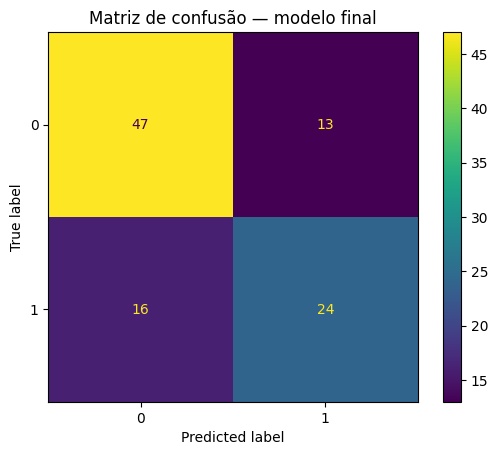

In [ ]:
# === Ajuste final do ensemble e avaliação no conjunto de teste ===
ensemble_model.fit(X_train, y_train)
y_proba_test = ensemble_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

results["Stacking (otimizado)"] = evaluate_classification(
    y_test, y_pred_test, ensemble_model.predict_proba(X_test)
)
trained_models["Stacking (otimizado)"] = ensemble_model

print(f"--- Relatório de classificação (teste | threshold: {best_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_test))
print(f"ROC-AUC (final): {results['Stacking (otimizado)']['roc_auc']:.4f}")


### Curvas ROC: modelos base vs. ensemble de stacking

ROC-AUC é a métrica principal do projeto, então ploto as curvas dos três modelos base (já ajustados *dentro* do ensemble de stacking, ou seja, treinados no conjunto de treino completo) contra o stacking final. Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo separa fraude de transações legítimas; a diagonal é um classificador aleatório (AUC = 0,5).


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# modelos base já ajustados no treino completo dentro do stacking (sem retreinar)
base_colors = {'XGBoost': '#4C72B0', 'LightGBM': '#55A868', 'CatBoost': '#8172B3'}
for name, color in base_colors.items():
    est = ensemble_model.named_estimators_[name]
    proba = est.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax, color=color)

RocCurveDisplay.from_predictions(y_test, y_proba_test, name='Stacking Ensemble',
                                 ax=ax, color='#C44E52', linewidth=2.5)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador aleatório (AUC = 0,50)')
ax.set_title('Curvas ROC — modelos base vs. ensemble de stacking', fontsize=13)
ax.set_xlabel('Taxa de falsos positivos')
ax.set_ylabel('Taxa de verdadeiros positivos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# comparação de ROC-AUC entre todos os modelos avaliados
comparison = show_results_table(results).sort_values('roc_auc')

COR_DESTAQUE = "#0B4FA8"
COR_BASE = "#EAEAEA"
cores = [COR_DESTAQUE if idx == comparison.index[-1] else COR_BASE for idx in comparison.index]

fig, ax = plt.subplots(figsize=(8, 5.5))
barras = ax.bar(comparison.index, comparison['roc_auc'], color=cores, width=0.6, zorder=3)

for barra, valor in zip(barras, comparison['roc_auc']):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.0015,
            f"{valor:.4f}", ha="center", va="bottom", fontsize=11, color="#404040")

ax.set_ylabel("ROC-AUC")
ax.set_title("Desempenho dos modelos (ROC-AUC)", fontsize=14, weight="bold", pad=15)
ax.grid(axis="y", color="#EDEDED", linewidth=0.75, zorder=0)
ax.grid(axis="x", visible=False)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False, bottom=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [ ]:
fitted_lgb = ensemble_model.named_estimators_['LightGBM']
importances = fitted_lgb.feature_importances_
features = fitted_lgb.feature_name_

df_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(7, 4))
sns.barplot(x='Importance', y='Feature', data=df_importance, hue='Feature', palette='Purples_r', legend=False)
plt.title('Top 15 features mais importantes (LightGBM)', fontsize=12, pad=12)
plt.xlabel('Importância (Split)', fontsize=10)
plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
# comparação final: ensemble vs. baseline dummy (reaproveitando os resultados já calculados)
roc_auc_dummy = results['Dummy (baseline)']['roc_auc']
roc_auc_ensemble = results['Stacking (otimizado)']['roc_auc']

print(f"ROC-AUC Dummy (baseline): {roc_auc_dummy:.4f}")
print(f"ROC-AUC Stacking (final): {roc_auc_ensemble:.4f}")
print(f"Ganho de aprendizado:     +{(roc_auc_ensemble - roc_auc_dummy):.4f} pontos")


## 10.1 Análise de erros e limitações

**Resposta:**
> Com o threshold de 0,11 (otimizado por F2), o ensemble final atinge recall de fraude de 0,60 e precisão de 0,34 no teste (ROC-AUC = 0,9031) — o trade-off esperado do F2, que aceita mais falsos positivos (clientes legítimos sinalizados para revisão) em troca de detectar mais fraudes. Ainda assim, cerca de 40% das fraudes escapam à detecção; se esse percentual é aceitável depende do contexto de negócio (custo de revisão manual vs. custo médio de uma fraude não detectada), uma decisão que caberia à área de risco, não só ao modelo. Não há sinais fortes de overfitting: o ROC-AUC out-of-fold (0,883) e o de teste (0,903) são próximos, sugerindo boa generalização dentro do próprio conjunto de treino disponível. Limitações relevantes: o PCA reduz a interpretabilidade das colunas `V*` (não é possível dizer qual variável original "causou" a decisão); os mapas de velocidade/grafo são uma "fotografia" da janela de treino e ficariam desatualizados em produção (*concept drift*), exigindo retreino periódico; e não há validação no conjunto de teste oficial do Kaggle, que não tem rótulos públicos — a avaliação depende inteiramente do holdout interno construído aqui.


In [ ]:
show_results_table(results).sort_values('roc_auc', ascending=False)


# 11. Comparação final dos modelos

| Modelo | ROC-AUC (teste) | Recall (fraude) | Precisão (fraude) | F1 (fraude) | Threshold |
|---|---:|---:|---:|---:|---:|
| Dummy (baseline) | 0,5010 | ~0,04 | ~0,04 | 0,036 | 0,50 |
| XGBoost | 0,8855 | 0,64 | 0,27 | 0,38 | 0,50 |
| LightGBM | 0,8809 | 0,64 | 0,27 | 0,37 | 0,50 |
| CatBoost | 0,8921 | 0,69 | 0,21 | 0,33 | 0,50 |
| Stacking (final) | 0,9031 | 0,60 | 0,34 | 0,44 | 0,11 (F2-otimizado) |

> **Comentário:** o CatBoost tem o melhor ROC-AUC individual e o maior recall isolado, mas com a menor precisão. O stacking com threshold ajustado por F2 entrega o melhor ROC-AUC geral e o melhor F1 de fraude entre as opções testadas, justificando sua escolha como modelo final — mesmo sacrificando um pouco de recall (0,60 vs. 0,69 do CatBoost) em favor de bem mais precisão (0,34 vs. 0,21).


# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed fixa (42) em todas as etapas | Reprodutibilidade dos resultados | Permite comparar reexecuções do notebook |
| Split treino/teste ordenado por `TransactionDT`, sem shuffle | Evitar vazamento temporal | Estimativa realista de desempenho em produção |
| Imputação por mediana + `StandardScaler` + PCA (90% variância) nas colunas `V*` | Alta dimensionalidade e multicolinearidade das features anônimas da Vesta | Reduz ruído e custo computacional, ao custo de interpretabilidade |
| Target encoding out-of-fold (`TimeSeriesSplit`) para colunas de alta cardinalidade | Evitar vazamento do alvo em colunas como `P_emaildomain` | Estimativa de desempenho mais confiável |
| Features de velocidade e de grafo ajustadas somente no treino | Evitar vazamento de informação do teste | Generalização mais realista |
| `scale_pos_weight` / `class_weight='balanced'` / `auto_class_weights='Balanced'` em vez de oversampling | Tratar o desbalanceamento (~3,5% de fraude) sem distorcer relações temporais/de entidade | Melhor recall da classe minoritária sem re-simular dados |
| Early stopping para definir o nº de iterações de cada modelo base | Evitar overfitting e custo computacional desnecessário | Nº de iterações "sob medida" para cada modelo (187–292) |
| Threshold de decisão otimizado por F2 (OOF), não pelo padrão 0,5 | Custo assimétrico entre perder uma fraude e bloquear um cliente legítimo | Recall priorizado sobre precisão na decisão final |
| Ausência de busca formal de hiperparâmetros (`grid`/`random search`) | Custo computacional em ~472 mil linhas × 3 modelos × 5 folds | Limitação assumida; ponto de melhoria futura |


# 13. Conclusão

**Conclusão:**
> O objetivo deste MVP era construir e avaliar modelos de Machine Learning para prever fraude em transações de cartão, comparando um baseline aleatório com modelos de gradient boosting e um ensemble via stacking. O resultado final — ROC-AUC de 0,9031 no stacking, contra 0,5010 do baseline dummy (+0,4020 pontos) — mostra que a combinação de engenharia de features orientada ao domínio (features temporais, de velocidade e de grafo/histórico de fraude) com prevenção cuidadosa de vazamento de dados (split temporal, encoding out-of-fold) foi central para o resultado, mais até do que a escolha do algoritmo em si — os três modelos base (XGBoost, LightGBM, CatBoost) chegaram a ROC-AUCs muito próximos entre si (0,88–0,89). O ajuste do threshold de decisão por F2-score alinhou a decisão final ao custo assimétrico do negócio (perder uma fraude custa mais do que bloquear indevidamente um cliente legítimo), resultando no melhor F1 de fraude entre todas as opções testadas.
>
> As principais limitações — ausência de busca formal de hiperparâmetros, interpretabilidade reduzida pelo PCA, mapas de velocidade/grafo estáticos (sujeitos a *concept drift*) e falta de validação no conjunto de teste oficial do Kaggle — apontam para os próximos passos naturais deste trabalho: uma busca de hiperparâmetros mais extensa (ex.: `Optuna` com poucos trials, focada no melhor modelo individual), submissão ao leaderboard público do Kaggle para uma segunda validação externa, e um plano de monitoramento/retraining periódico caso o modelo fosse levado a produção.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# === Salvamento dos artefatos (pré-processamento + modelos) ===
# Efêmero no runtime do Colab: para preservar entre sessões, baixe os arquivos manualmente
# (ex.: `from google.colab import files; files.download(...)`) ou monte seu próprio Google Drive.
ARTIFACTS_DIR = DATA_PATH

joblib.dump(imputer, os.path.join(ARTIFACTS_DIR, 'imputer_v_cols.pkl'))
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, 'scaler_v_cols.pkl'))
joblib.dump(pca, os.path.join(ARTIFACTS_DIR, 'pca_v_cols.pkl'))
joblib.dump(target_encoder, os.path.join(ARTIFACTS_DIR, 'target_encoder.pkl'))
joblib.dump(onehot_encoder, os.path.join(ARTIFACTS_DIR, 'onehot_encoder.pkl'))
joblib.dump(velocity_maps, os.path.join(ARTIFACTS_DIR, 'velocity_maps.pkl'))
joblib.dump(graph_maps, os.path.join(ARTIFACTS_DIR, 'graph_features.pkl'))

with open(os.path.join(ARTIFACTS_DIR, 'train_columns.pkl'), 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

joblib.dump(xgb_model, os.path.join(ARTIFACTS_DIR, 'xgb_model.pkl'))
joblib.dump(lgb_model, os.path.join(ARTIFACTS_DIR, 'lgb_model.pkl'))
joblib.dump(cat_model, os.path.join(ARTIFACTS_DIR, 'cat_model.pkl'))
joblib.dump(ensemble_model, os.path.join(ARTIFACTS_DIR, 'ensemble_model.pkl'))

model_metadata = {
    'best_threshold': best_threshold,
    'best_fbeta_validation': best_fbeta,
    'timestamp': pd.Timestamp.now(),
    'oof_roc_auc': roc_auc_score(y_train, y_proba_oof),
    'test_roc_auc': results['Stacking (otimizado)']['roc_auc'],
    'base_model_iterations': best_iters,
}
joblib.dump(model_metadata, os.path.join(ARTIFACTS_DIR, 'model_metadata.pkl'))
print(model_metadata)


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

**Não aplicável a este projeto.** Para dados tabulares como os desta competição (mistura de
colunas numéricas, categóricas e features anonimizadas), ensembles de árvores de decisão
(gradient boosting) são estado da arte e foram, historicamente, a abordagem predominante
entre as soluções mais bem colocadas da própria competição Kaggle IEEE-CIS Fraud Detection.
Redes neurais profundas tendem a exigir mais dados/tuning para superar gradient boosting
em problemas tabulares deste porte, sem benefício claro que justifique a complexidade
adicional no escopo deste MVP.
